In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
# Load data
df = pd.read_csv("dataset/cleaned_data.csv")

# FEATURE ENGINEERING

In [39]:
# Convert to datetime
df["launched"] = pd.to_datetime(df["launched"])
df["deadline"] = pd.to_datetime(df["deadline"])

# Clean monetary columns
df["goal"] = df["goal"].str.replace(r"[^\d.]", "", regex=True).astype(float)
df["pledged"] = df["pledged"].str.replace(r"[^\d.]", "", regex=True).astype(float)

# Convert to categorical
df["launched_month_name"] = df["launched_month_name"].astype("category")
df["state"] = df["state"].astype("category")
df["country"] = df["country"].astype("category")
df["category"] = df["category"].astype("category")

# Campaign duration
df["campaign_duration_days"] = (df["deadline"] - df["launched"]).dt.days

# OUTLIERS DETECTION 

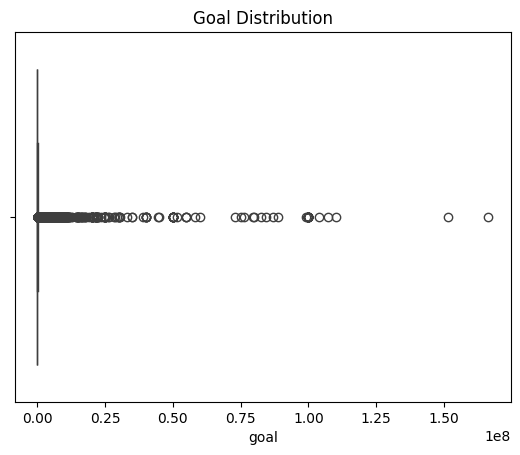

In [40]:
# Outlier Detection using IQR

Q1 = df["goal"].quantile(0.25)
Q3 = df["goal"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["goal"] < lower) | (df["goal"] > upper)]

sns.boxplot(x=df["goal"])
plt.title("Goal Distribution")
plt.show()

In [41]:
# Goal Range Binning

bins = [0, 1000, 5000, 10000, 25000, 50000, 100000, 500000, df["goal"].max()]
labels = [
    "0-1K", "1K-5K", "5K-10K", "10K-25K",
    "25K-50K", "50K-100K", "100K-500K", "500K+"
]

df["goal_range"] = pd.cut(df["goal"], bins=bins, labels=labels)

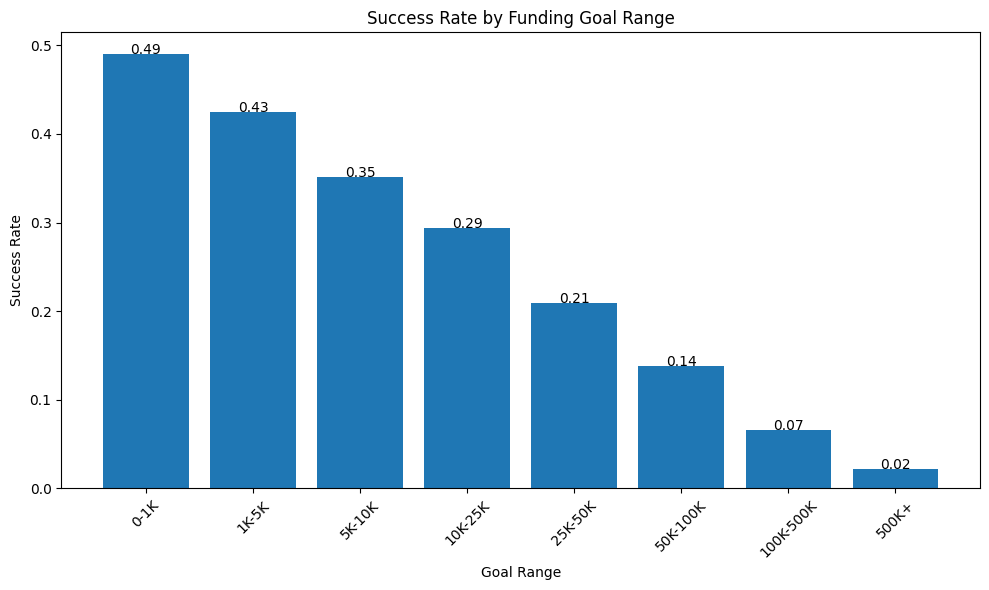

In [42]:
# Success Rate by Goal Range

goal_analysis = (
    df.groupby("goal_range")["state"]
      .apply(lambda x: (x == "Successful").mean())
      .reset_index(name="success_rate")
)

goal_analysis = goal_analysis.sort_values(by="goal_range")

plt.figure(figsize=(10, 6))
bars = plt.bar(goal_analysis["goal_range"], goal_analysis["success_rate"])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.2f}",
             ha="center")

plt.xlabel("Goal Range")
plt.ylabel("Success Rate")
plt.title("Success Rate by Funding Goal Range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
# Expected Value Analysis

summary = df.groupby("goal_range").agg(
    success_rate=("state", lambda x: (x == "Successful").mean()),
    avg_pledged=("pledged", "mean")
)

summary["expected_value"] = (
    summary["success_rate"] * summary["avg_pledged"]
)

summary = summary.reset_index()


In [44]:
# Realistic vs Unrealistic Goal Classification

category_median = df.groupby("category")["goal"].median()
df["category_median"] = df["category"].map(category_median)

df["goal_type"] = np.where(
    df["goal"] > 3 * df["category_median"],
    "Unrealistic",
    "Realistic"
)

goal_effect = df.groupby("goal_type").agg(
    total_projects=("goal", "count"),
    success_rate=("state", lambda x: (x == "Successful").mean())
).reset_index()

print(goal_effect)

     goal_type  total_projects  success_rate
0    Realistic          298903      0.397273
1  Unrealistic           75950      0.198881
